# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych
from src.dataset import load_mnist_tensor

import matplotlib.pyplot as plt
import torch 
import numpy as np

# MNIST Dataset

In [2]:
dataset="mnist"

sigma=1.0
n_bins=220
n_samples=4
k=4.0
n_replicas=3

In [3]:
# def apply_temperature(x, k=1.0):
#     """x in [0,1]. k>1 sharpens, k<1 flattens."""
#     x = x.clamp(1e-6, 1 - 1e-6)  # avoid log(0)
#     logits = torch.log(x / (1 - x))  # inverse sigmoid
#     logits = logits * k              # scale by temperature
#     return torch.sigmoid(logits)     # back to [0,1]

# x = load_mnist_tensor(train=False, normalize_to_minus1_1=False)

# ks = np.linspace(1.0, k, n_replicas)
# fig, axes = plt.subplots(n_samples, len(ks), figsize=(len(ks) * 2, n_samples*2))

# for row in range(n_samples):
#     for col, k in enumerate(ks):
#         img = apply_temperature(x[row, 0], k=k)
#         axes[row, col].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
#         axes[row, col].axis("off")
#         if row == 0:
#             axes[row, col].set_title(f"k={k}")

# plt.tight_layout()
# plt.show()

In [4]:
# _ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=False)

In [5]:
# _ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=True)

# Composed Dataset

In [6]:
dataset="composed"

Accept analytical: 0.776 non-analytical: 0.820


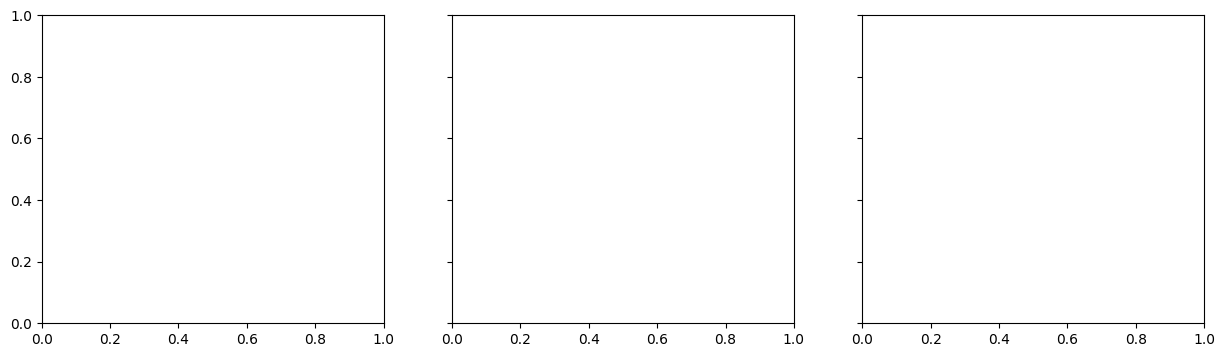

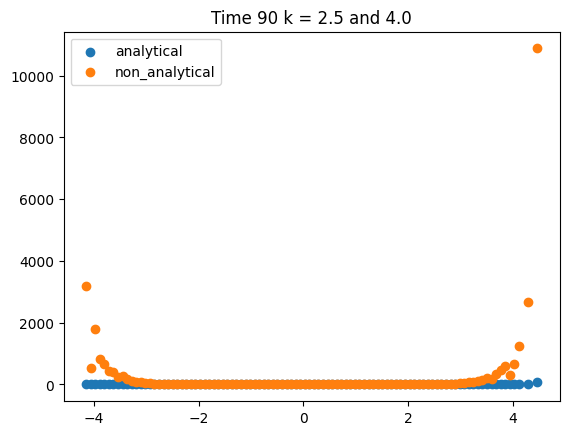

Time 90 xs 0.00 xt -0.00 swap 0.78 
Accept analytical: 0.877 non-analytical: 0.845


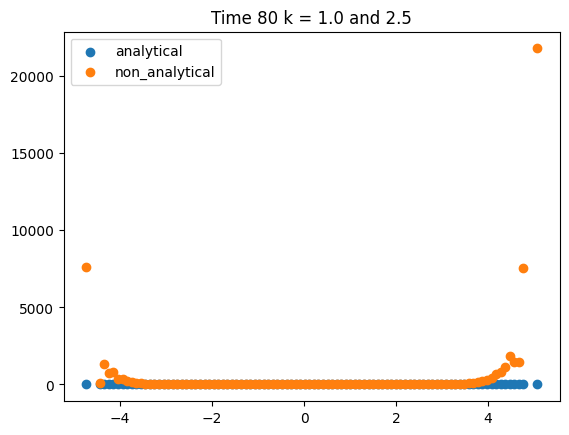

Time 80 xs 0.01 xt 0.01 swap 0.88 
Accept analytical: 0.757 non-analytical: 0.857


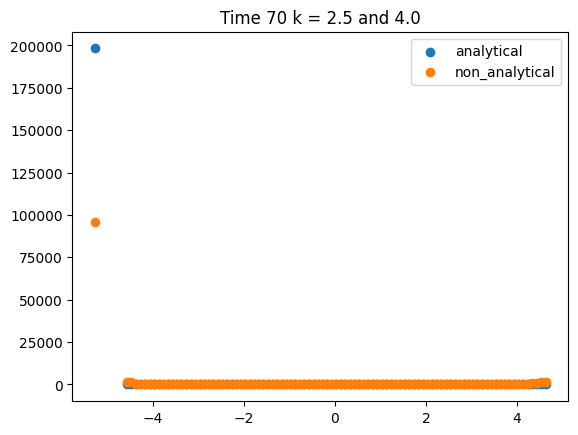

Time 70 xs 0.01 xt 0.01 swap 0.76 
Accept analytical: 0.863 non-analytical: 0.895


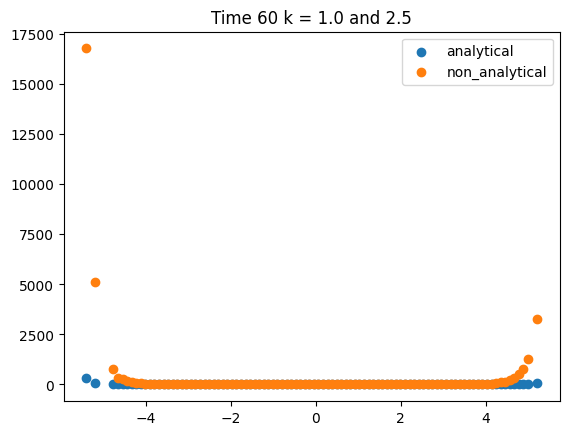

Time 60 xs 0.02 xt 0.03 swap 0.86 
Accept analytical: 0.738 non-analytical: 0.892


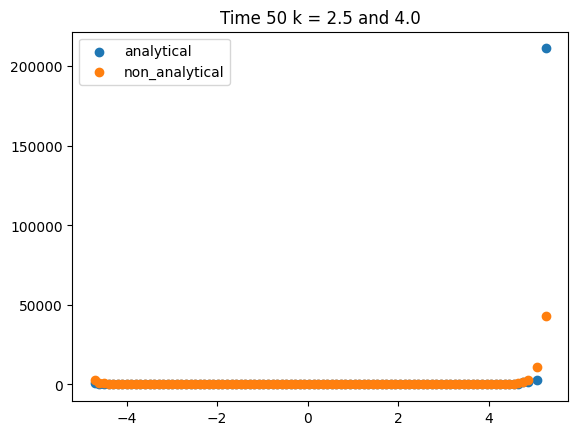

Time 50 xs 0.03 xt 0.03 swap 0.74 
Accept analytical: 0.873 non-analytical: 0.907


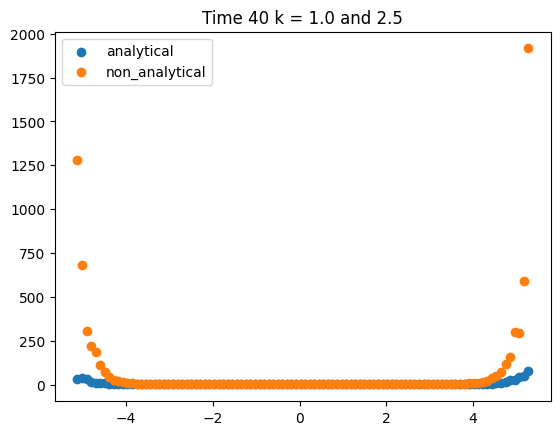

Time 40 xs 0.04 xt 0.04 swap 0.87 
Accept analytical: 0.764 non-analytical: 0.833


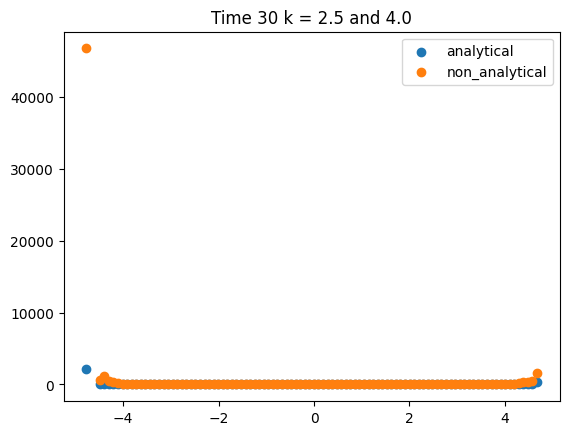

Time 30 xs 0.04 xt 0.05 swap 0.76 
Accept analytical: 0.919 non-analytical: 0.898


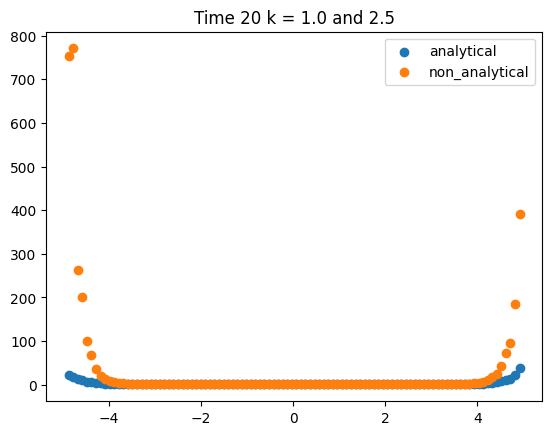

Time 20 xs 0.05 xt 0.07 swap 0.92 


<Figure size 640x480 with 0 Axes>

In [7]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins,n_replicas=n_replicas,n_samples=n_samples, k=k, replica_swaps=True, analytical=True)

Time 90 xs -0.00 xt -0.01 swap 0.82 
Time 80 xs -0.01 xt 0.01 swap 0.86 
Time 70 xs 0.02 xt 0.01 swap 0.86 
Time 60 xs 0.04 xt 0.02 swap 0.93 
Time 50 xs 0.01 xt 0.03 swap 0.87 
Time 40 xs 0.01 xt 0.06 swap 0.92 
Time 30 xs 0.04 xt 0.05 swap 0.83 
Time 20 xs 0.26 xt 0.05 swap 0.89 


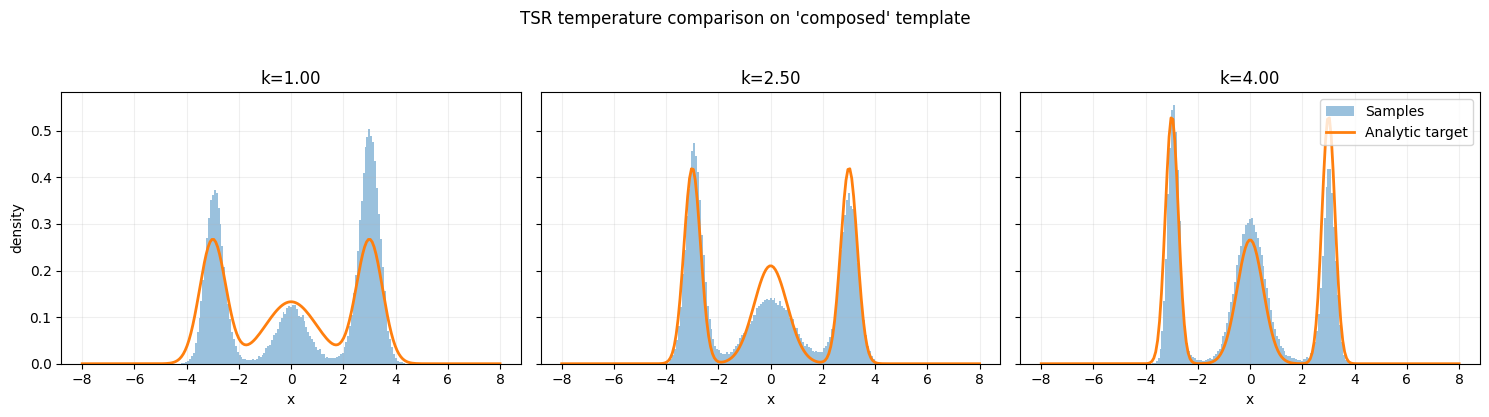

In [8]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_replicas=n_replicas, n_samples=n_samples, k=k, replica_swaps=True, analytical=False)

In [ ]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins,n_replicas=n_replicas, n_samples=n_samples, k=k, replica_swaps=False)